# dFBA híbrido Zenteno-Henriques limpio

Base reproducible para fermentación vínica en COBRApy:

- carga y preparación de Yeast-GEM;
- medio vínico anaeróbico;
- IDs y estados clave;
- restricciones dinámicas tipo Zenteno;
- hooks Henriques para hexosas y productos fermentativos;
- protein turnover, `N_rec` y GAM variable;
- dFBA secuencial con colocaciones ortogonales Radau IIA.

No incluye PSO, calibración ni export MPCC/Notebook 2.


In [39]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cobra
from cobra.flux_analysis import pfba, flux_variability_analysis

OUT_DIR = Path("out")
OUT_DIR.mkdir(exist_ok=True)

SBML_PATH = Path("yeast-GEM.xml")
assert SBML_PATH.is_file(), f"No se encontro SBML: {SBML_PATH.resolve()}"

RUN_SMOKE_TEST = True
SMOKE_NFE = 12
SMOKE_T_END_H = 172.0
SMOKE_N_ITER = 1
EPS = 1e-9

print(f"SBML: {SBML_PATH.resolve()}")
print(f"OUT_DIR: {OUT_DIR.resolve()}")


SBML: C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\DC_dFBA_Zenteno\yeast-GEM.xml
OUT_DIR: C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\DC_dFBA_Zenteno\out


## 1. Carga del modelo

Las funciones dinámicas usan contextos `with model as m:` para evitar que los
bounds de un nodo de colocación contaminen los siguientes.


In [40]:
model = cobra.io.read_sbml_model(str(SBML_PATH))

print("Modelo cargado")
print(f"- Metabolitos: {len(model.metabolites)}")
print(f"- Reacciones: {len(model.reactions)}")
print(f"- Genes: {len(model.genes)}")

try:
    model.solver = "glpk"
except Exception as exc:
    warnings.warn(f"No se pudo fijar GLPK; se usa solver por defecto: {exc}")


Modelo cargado
- Metabolitos: 2806
- Reacciones: 4131
- Genes: 1161


## 2. IDs, estados y parametros

Los IDs provienen del notebook original. Se separan como estados externos cuatro aminoacidos clave para aromas: leucina (`r_1899`), valina (`r_1914`), fenilalanina (`r_1903`) y metionina (`r_1902`). `N_gN_L` queda como pool agregado del resto del YAN.

In [41]:
RXN = {
    "biomass": "r_2111",
    "cofactor_pseudoreaction": "r_4598",
    "glucose": "r_1714",
    "fructose": "r_1709",
    "ethanol": "r_1761",
    "oxygen": "r_1992",
    "atpm": "r_4046",
    "protein": "r_4047",
    "ammonium": "r_1654",
    "leucine": "r_1899",
    "valine": "r_1914",
    "phenylalanine": "r_1903",
    "methionine": "r_1902",
    "glycerol": "r_1808",
    "acetate": "r_1634",
    "succinate": "r_2056",
    "ethyl_acetate": "r_1765",
    "isoamyl_acetate": "r_1862",
    "isoamyl_alcohol": "r_1865",
    "isobutyl_acetate": "r_1867",
    "isobutanol": "r_1866",
}

METS_ANAEROBIC_BYPASS = [
    "s_3714[c]", "s_1198[c]", "s_1203[c]",
    "s_1207[c]", "s_1212[c]", "s_0529[c]",
]

ALL_N_SOURCE_IDS = [
    "r_1654", "r_1904", "r_1891", "r_1889", "r_1880", "r_1881",
    "r_1873", "r_1879", "r_1810", "r_1906", "r_1911", "r_1914",
    "r_1899", "r_1897", "r_1903", "r_1913", "r_1912", "r_1893",
    "r_1900", "r_1902", "r_1883", "r_1987", "r_1800",
]

KINETIC_N_SOURCE_IDS = [
    "r_1654", "r_1879", "r_1891", "r_1889", "r_1906",
    "r_1911", "r_1873", "r_1912",
    "r_1899", "r_1914", "r_1903", "r_1902",
]

N_ATOMS = {
    "r_1654": 1.0, "r_1879": 4.0, "r_1891": 2.0, "r_1889": 1.0,
    "r_1906": 1.0, "r_1911": 1.0, "r_1873": 1.0,
    "r_1912": 2.0, "r_1899": 1.0, "r_1914": 1.0,
    "r_1903": 1.0, "r_1902": 1.0,
}

AROMA_AA = {
    "leu": {"rxn": "r_1899", "state": "AA_leu_gN_L", "label": "leucine", "init_frac_yan": 0.05},
    "val": {"rxn": "r_1914", "state": "AA_val_gN_L", "label": "valine", "init_frac_yan": 0.05},
    "phe": {"rxn": "r_1903", "state": "AA_phe_gN_L", "label": "phenylalanine", "init_frac_yan": 0.03},
    "met": {"rxn": "r_1902", "state": "AA_met_gN_L", "label": "methionine", "init_frac_yan": 0.02},
}
AROMA_AA_RXN_IDS = {cfg["rxn"] for cfg in AROMA_AA.values()}
AROMA_AA_STATE_NAMES = [cfg["state"] for cfg in AROMA_AA.values()]

# Perfil de N: pool agregado + aminoacidos clave. Se normaliza para mantener YAN total.
N_PROFILE = {
    "r_1654": 0.30, "r_1879": 0.18, "r_1891": 0.10,
    "r_1889": 0.05, "r_1906": 0.05, "r_1911": 0.05,
    "r_1873": 0.05, "r_1912": 0.10,
    "r_1899": 0.05, "r_1914": 0.05, "r_1903": 0.03, "r_1902": 0.02,
}
_prof_sum = sum(N_PROFILE.get(rid, 0.0) for rid in KINETIC_N_SOURCE_IDS)
N_PROFILE = {rid: N_PROFILE.get(rid, 0.0) / max(_prof_sum, EPS) for rid in KINETIC_N_SOURCE_IDS}

MW = {
    "N": 0.014007,
    "glucose": 0.180156,
    "fructose": 0.180156,
    "ethanol": 0.046070,
    "oxygen": 0.031998,
    "isoamyl_acetate": 0.130186,
    "ethyl_acetate": 0.088106,
}

STATE_NAMES = [
    "X_gDW_L", "XA_gDW_L", "XV_gDW_L", "XD_gDW_L",
    "N_gN_L", "G_g_L", "F_g_L", "E_g_L", "O2_g_L",
    "Prot_g_L", "Carb_g_L", "Nrec_gN_L",
    "AA_leu_gN_L", "AA_val_gN_L", "AA_phe_gN_L", "AA_met_gN_L",
    "isoamyl_acetate_mg_L", "ethyl_acetate_mg_L",
]
BIOMASS_POOL_NAMES = ["X_gDW_L", "XA_gDW_L", "XV_gDW_L", "XD_gDW_L"]
STATE_IDX = {name: i for i, name in enumerate(STATE_NAMES)}

PARAMS = {
    "MU0": 0.18, "YXN": 19.69, "YXG": 1.60, "YXF": 1.60,
    "YEG": 0.49, "YEF": 0.49, "Kn": 0.01, "Kg": 7.5,
    "Kf": 7.5, "Kig": 55.0, "Kie": 40.0,
    "betaG": 0.225, "betaF": 0.225, "Kd": 0.00044,
    "mrate0": 0.01,
    "T_base_K": 298.15, "T_steps_h": [36.0, 96.0],
    "T_deltas_K": [5.0, 3.0], "T_steep": 0.5,
    "O2_vmax": 2.0, "O2_K_g_L": 0.002,
    "O2_depletion_threshold": 1e-9,
    "prot_content0": 0.46, "carb_content0": 0.37,
    "rna_frac": 0.06, "gam_base": 30.49, "ngam_base": 0.7,
    "gam_coeff_p": 16.965, "gam_coeff_r": 1.638, "gam_coeff_c": 5.210,
    "turnover_lambda": 0.0003, "k_death_prot": 0.005,
    "y_n_from_prot": 0.16, "k_nrec_uptake": 0.10,
    "vprot_floor_frac": 0.90,
    "n_depletion_threshold": 1e-3,
    "n_limited_threshold": 0.02,
    "lag_end_h": 4.0,
    "decay_start_h": 60.0,
    "growth_lock_frac": 1.0,
    "kinetic_form": "zenteno",  # "zenteno" o "henriques_hexose"
    "enable_henriques_product_caps": True,
    "enable_henriques_aroma_ode": True,
    "aroma_driver": "fermentation_hexose",  # derivado de betaG/betaF de Zenteno, con T(t)
    "component_loss_tracks_biomass_death": True,
    "x_total_from_active_dead": True,  # X_gDW_L = XA_gDW_L + XD_gDW_L
    "enable_viable_biomass_loss": True,
    "xv_ethanol_loss_phases": ("stationary", "decay"),
    "xv_kEdeath": 0.01,
    "xv_ethanol_half_g_L": 80.0,
    "xv_ethanol_hill": 4.0,
    "dead_equivalent_from_viability_loss_frac": 0.0,
    "initial_total_yan_gN_L": 0.14,
    "enable_aroma_aa_states": True,
    "aa_uptake_vmax_gN_gDW_h": 0.012,
    "aa_uptake_K_gN_L": 0.002,
    "enable_aroma_aa_modulation": True,
    "aroma_aa_K_gN_L": 0.002,
    "aroma_aa_floor": 0.05,
    "aroma_product_aa_dependency": {
        "isoamyl_acetate": {"leu": 1.0},
        "isoamyl_alcohol": {"leu": 1.0},
        "isobutyl_acetate": {"val": 1.0},
        "methionol": {"met": 1.0},
        "phenylethanol": {"phe": 1.0},
    },
    "product_k": {
        "isoamyl_acetate": 2.0e-5,
        "ethyl_acetate": 2.0e-4,
    },
    "henriques_vmaxG": 12.0,
    "henriques_vmaxF": 12.0,
    "henriques_kG": 10.0,
    "henriques_kF": 10.0,
    "henriques_KEi": 850.0,
}

print(f"Estados definidos: {len(STATE_NAMES)}")
print("Fuentes N cineticas:", KINETIC_N_SOURCE_IDS)
print("Aminoacidos aroma separados:", AROMA_AA)


Estados definidos: 14
Fuentes N cineticas: ['r_1654', 'r_1879', 'r_1891', 'r_1889', 'r_1906', 'r_1911', 'r_1873', 'r_1912', 'r_1899']


## 3. Validación y preparación estructural


In [42]:
def has_rxn(mdl, rid):
    return bool(rid) and rid in {r.id for r in mdl.reactions}


def get_rxn(mdl, rid):
    return mdl.reactions.get_by_id(rid) if has_rxn(mdl, rid) else None


def validate_ids(mdl, rxn_ids=None, met_ids=None, required_rxn=()):
    """Reporta presencia de IDs; falla solo para reacciones requeridas."""
    rxn_ids = rxn_ids or []
    met_ids = met_ids or []
    rxn_set = {r.id for r in mdl.reactions}
    met_set = {m.id for m in mdl.metabolites}
    rows = []
    for rid in rxn_ids:
        ok = rid in rxn_set
        rows.append({
            "kind": "reaction",
            "id": rid,
            "found": ok,
            "name": get_rxn(mdl, rid).name if ok else "",
        })
    for mid in met_ids:
        key = mid if mid in met_set else mid.replace("[c]", "")
        ok = key in met_set
        rows.append({
            "kind": "metabolite",
            "id": mid,
            "found": ok,
            "name": mdl.metabolites.get_by_id(key).name if ok else "",
        })
    missing_required = [rid for rid in required_rxn if rid not in rxn_set]
    if missing_required:
        raise KeyError(f"Faltan reacciones requeridas: {missing_required}")
    return pd.DataFrame(rows)


def find_metabolite(mdl, mid):
    """Busca metabolito con o sin sufijo [c]."""
    met_ids = {m.id for m in mdl.metabolites}
    if mid in met_ids:
        return mdl.metabolites.get_by_id(mid)
    clean = mid.replace("[c]", "")
    if clean in met_ids:
        return mdl.metabolites.get_by_id(clean)
    return None


def adjust_biomass_for_anaerobiosis(mdl, biomass_id=RXN["cofactor_pseudoreaction"], bypass_mets=METS_ANAEROBIC_BYPASS):
    """Elimina términos problemáticos de la pseudorreacción de cofactores bajo anaerobiosis."""
    rxn = get_rxn(mdl, biomass_id)
    if rxn is None:
        warnings.warn(f"No existe pseudorreacción anaeróbica {biomass_id}; no se ajusta.")
        return []
    updates = {}
    removed = []
    for mid in bypass_mets:
        met = find_metabolite(mdl, mid)
        if met is None:
            continue
        coef = rxn.metabolites.get(met, 0.0)
        if coef != 0:
            updates[met] = -coef
            removed.append((met.id, float(coef)))
    if updates:
        rxn.add_metabolites(updates)
    return removed


id_report = validate_ids(
    model,
    rxn_ids=list(RXN.values()) + KINETIC_N_SOURCE_IDS,
    met_ids=METS_ANAEROBIC_BYPASS,
    required_rxn=[RXN["biomass"], RXN["cofactor_pseudoreaction"], RXN["glucose"], RXN["fructose"], RXN["atpm"]],
)
display(id_report)

removed_biomass_terms = adjust_biomass_for_anaerobiosis(model)
print("Terminos removidos de r_4598 por anaerobiosis:", removed_biomass_terms)

if has_rxn(model, RXN["biomass"]):
    model.objective = RXN["biomass"]
    model.objective_direction = "max"


,kind,id,found,name
0,reaction,r_2111,True,growth
1,reaction,r_4598,True,cofactor pseudoreaction
2,reaction,r_1714,True,D-glucose exchange
3,reaction,r_1709,True,D-fructose exchange
4,reaction,r_1761,True,ethanol exchange
5,reaction,r_1992,True,oxygen exchange
6,reaction,r_4046,True,non-growth associated maintenance reaction
7,reaction,r_4047,True,protein pseudoreaction
8,reaction,r_1654,True,ammonium exchange
9,reaction,r_1899,True,L-leucine exchange


Terminos removidos de r_4598 por anaerobiosis: [('s_3714', -9.99999997475243e-07), ('s_1198', -0.00264999992214143), ('s_1203', -0.000150000007124618), ('s_1207', -0.000569999974686652), ('s_1212', -0.00270000007003546), ('s_0529', -0.000190000006114133)]


## 4. Medio vínico anaeróbico

Replica el sentido del notebook original: O2 cerrado, hexosas como uptake,
N cinético controlado, suplementos anaeróbicos, trazas de vitaminas/iones,
productos abiertos y ATPM basal.


In [43]:
DEFAULT_WINE_MEDIUM = {
    "vitamin_trace_lb": -1e-2,
    "ion_trace_lb": -1e-3,
    "atpm_lb": 0.7,
    "atpm_ub": 0.7,
}

WINE_MEDIUM_GROUPS = [
    ("anaerobiosis_o2_off", [RXN["oxygen"]], 0.0, 0.0),
    ("anaerobic_supplements", ["r_1757", "r_1915", "r_1994", "r_2106", "r_2134", "r_2137", "r_2189"], -1000.0, 0.0),
    ("carbon_sources", [RXN["glucose"], RXN["fructose"]], -1000.0, 0.0),
    ("all_n_sources_closed", ALL_N_SOURCE_IDS, 0.0, 0.0),
    ("kinetic_n_sources_open", KINETIC_N_SOURCE_IDS, -1000.0, 0.0),
    ("vitamins", ["r_2067", "r_1671", "r_1967", "r_2028", "r_1548", "r_2038", "r_1947"], "vitamin", 0.0),
    ("phosphate", ["r_2005"], -1000.0, 0.0),
    ("sulfate", ["r_2060"], -1000.0, 0.0),
    ("ions", ["r_2020", "r_1861", "r_4596", "r_4597", "r_4594", "r_4600", "r_4595", "r_4593"], "ion", 0.0),
    ("products_open", [RXN[k] for k in ["ethanol", "glycerol", "acetate", "succinate", "ethyl_acetate", "isoamyl_acetate", "isoamyl_alcohol", "isobutyl_acetate", "isobutanol"]] + ["r_1549", "r_1546", "r_1552"], 0.0, 1000.0),
    ("water_protons", ["r_2100", "r_1832"], -1000.0, 1000.0),
]


def set_bounds(mdl, rid, lb=None, ub=None, group="", log=None):
    """Aplica bounds si existe la reacción y registra el cambio."""
    rxn = get_rxn(mdl, rid)
    rec = {"group": group, "rid": rid, "found": rxn is not None, "old_lb": None, "old_ub": None, "new_lb": None, "new_ub": None, "name": ""}
    if rxn is None:
        if log is not None:
            log.append(rec)
        return rec
    rec.update({"old_lb": float(rxn.lower_bound), "old_ub": float(rxn.upper_bound), "name": rxn.name})
    if lb is not None:
        rxn.lower_bound = float(lb)
    if ub is not None:
        rxn.upper_bound = float(ub)
    rec.update({"new_lb": float(rxn.lower_bound), "new_ub": float(rxn.upper_bound)})
    if log is not None:
        log.append(rec)
    return rec


def apply_wine_medium(mdl, cfg=None, verbose=True):
    """Aplica el medio vínico anaeróbico de referencia."""
    cfg = dict(DEFAULT_WINE_MEDIUM if cfg is None else cfg)
    log = []
    for group, ids, lb, ub in WINE_MEDIUM_GROUPS:
        lb_val = cfg["vitamin_trace_lb"] if lb == "vitamin" else cfg["ion_trace_lb"] if lb == "ion" else lb
        for rid in ids:
            set_bounds(mdl, rid, lb=lb_val, ub=ub, group=group, log=log)

    set_bounds(mdl, "r_0713", lb=0.0, group="shuttles", log=log)
    set_bounds(mdl, "r_0714", lb=0.0, group="shuttles", log=log)
    set_bounds(mdl, "r_0487", ub=0.0, group="shuttles", log=log)
    set_bounds(mdl, RXN["atpm"], lb=cfg["atpm_lb"], ub=cfg["atpm_ub"], group="atpm", log=log)

    df = pd.DataFrame(log)
    if verbose:
        print(f"Bounds aplicados: {df['found'].sum()}/{len(df)} reacciones encontradas")
        missing = sorted(df.loc[~df["found"], "rid"].unique())
        if missing:
            print("IDs no encontrados:", missing)
    return df


medium_log = apply_wine_medium(model, DEFAULT_WINE_MEDIUM, verbose=True)
base_bounds = {r.id: (float(r.lower_bound), float(r.upper_bound)) for r in model.reactions}


Bounds aplicados: 77/77 reacciones encontradas


## 5. Diagnóstico FBA/FVA mínimo


In [44]:
def quick_fba_check(mdl, key_rxn=None):
    """Optimiza una vez y reporta flujos clave."""
    key_rxn = key_rxn or [RXN["biomass"], RXN["cofactor_pseudoreaction"], RXN["glucose"], RXN["fructose"], RXN["ethanol"], RXN["oxygen"], RXN["atpm"], RXN["protein"]]
    sol = mdl.optimize()
    print(f"status: {sol.status}")
    print(f"objective: {sol.objective_value}")
    rows = []
    for rid in key_rxn:
        if has_rxn(mdl, rid):
            r = get_rxn(mdl, rid)
            rows.append({"rid": rid, "name": r.name, "lb": r.lower_bound, "ub": r.upper_bound, "flux": float(sol.fluxes.get(rid, np.nan))})
    return sol, pd.DataFrame(rows)


def targeted_fva_check(mdl, rxn_ids, fraction_of_optimum=0.99):
    """FVA acotado a reacciones de interés."""
    ids = [rid for rid in rxn_ids if has_rxn(mdl, rid)]
    if not ids:
        return pd.DataFrame()
    return flux_variability_analysis(mdl, reaction_list=ids, fraction_of_optimum=fraction_of_optimum)


solution_base, fba_key_df = quick_fba_check(model)
display(fba_key_df)

fva_ids = [RXN["biomass"], RXN["cofactor_pseudoreaction"], RXN["glucose"], RXN["fructose"], RXN["ethanol"], RXN["oxygen"], RXN["atpm"], RXN["protein"], RXN["isoamyl_acetate"], RXN["isoamyl_alcohol"]]
try:
    fva_key_df = targeted_fva_check(model, fva_ids, fraction_of_optimum=0.99)
    display(fva_key_df)
except Exception as exc:
    warnings.warn(f"FVA minimo fallo; continuar con dFBA: {exc}")


status: optimal
objective: 0.275482098690562


,rid,name,lb,ub,flux
0,r_2111,growth,0.0,1000.0,0.275482
1,r_4598,cofactor pseudoreaction,0.0,1000.0,0.275482
2,r_1714,D-glucose exchange,-1000.0,0.0,0.000000
3,r_1709,D-fructose exchange,-1000.0,0.0,-17.036921
4,r_1761,ethanol exchange,0.0,1000.0,0.000000
5,r_1992,oxygen exchange,0.0,0.0,0.000000
6,r_4046,non-growth associated maintenance reaction,0.7,0.7,0.700000
7,r_4047,protein pseudoreaction,0.0,1000.0,0.275482


,minimum,maximum
r_2111,0.272727,0.275482
r_4598,0.272727,0.275482
r_1714,-1000.000000,0.000000
r_1709,-1000.000000,0.000000
r_1761,0.000000,1000.000000
r_1992,0.000000,0.000000
r_4046,0.700000,0.700000
r_4047,0.272727,0.275482
r_1862,0.000000,581.640874
r_1865,0.000000,1000.000000


## 6. Restricciones dinámicas tipo Zenteno

Los límites son magnitudes positivas. Para uptakes COBRA se aplican como
`lower_bound = -limit`, `upper_bound <= 0`.


In [45]:
R_GAS = 8.314


def dynamic_temperature(t_h, params=PARAMS):
    """Perfil térmico: usa params['temperature_profile_df'] si existe; si no, perfil suave base."""
    profile = params.get("temperature_profile_df", None)
    if profile is not None and len(profile):
        t_arr = np.asarray(profile["t_h"], dtype=float)
        T_arr = np.asarray(profile["T_K"], dtype=float)
        order = np.argsort(t_arr)
        t_arr = t_arr[order]
        T_arr = T_arr[order]
        if params.get("temperature_profile_mode", "step") == "linear":
            return float(np.interp(float(t_h), t_arr, T_arr))
        idx = int(np.clip(np.searchsorted(t_arr, float(t_h), side="right") - 1, 0, len(T_arr) - 1))
        return float(T_arr[idx])

    val = float(params["T_base_K"])
    for step_t, delta_t in zip(params.get("T_steps_h", []), params.get("T_deltas_K", [])):
        sigmoid = 1.0 / (1.0 + math.exp(-float(params.get("T_steep", 0.5)) * (float(t_h) - float(step_t))))
        val += float(delta_t) * sigmoid
    return val


def death_rate_T(E_g_L, T_K, params=PARAMS):
    """Tasa de muerte dependiente de etanol y temperatura."""
    Td = -0.0001 * E_g_L**3 + 0.0049 * E_g_L**2 - 0.1279 * E_g_L + 315.89
    s = 0.5 * (1.0 + math.tanh(0.5 * (T_K - Td)))
    base = params["Kd"] * math.exp(0.0415 * E_g_L + (130000.0 * (T_K - 305.65)) / (305.65 * R_GAS * T_K))
    return float(base * s)


def viability_loss_rate(E_g_L, params=PARAMS):
    """Perdida de biomasa viable XV inducida por etanol; proxy de caida de CFU."""
    if not params.get("enable_viable_biomass_loss", True):
        return 0.0
    E = max(0.0, float(E_g_L))
    kmax = max(0.0, float(params.get("xv_kEdeath", 0.0)))
    half = max(float(params.get("xv_ethanol_half_g_L", 80.0)), EPS)
    hill = max(float(params.get("xv_ethanol_hill", 4.0)), EPS)
    if E <= 0.0 or kmax <= 0.0:
        return 0.0
    Eh = E**hill
    return float(kmax * Eh / (Eh + half**hill + EPS))


def n_fraction_map():
    """Mapea gN/gDW/h a mmol/gDW/h por fuente de N."""
    return {rid: N_PROFILE.get(rid, 0.0) / max(N_ATOMS.get(rid, 1.0) * MW["N"], EPS) for rid in KINETIC_N_SOURCE_IDS}


N_FRAC_MAP = n_fraction_map()


def aroma_aa_states(state):
    """Concentraciones externas de aminoacidos clave en gN/L."""
    return {
        key: max(0.0, float(state.get(cfg["state"], 0.0)))
        for key, cfg in AROMA_AA.items()
    }


def total_external_yan_gN_L(state, params=PARAMS):
    """YAN externo total = pool agregado + aminoacidos clave separados."""
    total = max(0.0, float(state.get("N_gN_L", 0.0)))
    if params.get("enable_aroma_aa_states", True):
        total += sum(aroma_aa_states(state).values())
    return float(total)


def amino_acid_uptake_caps(state, params=PARAMS):
    """Caps de uptake por aminoacido separado, en mmol/gDW/h."""
    if not params.get("enable_aroma_aa_states", True):
        return {}
    vmax = max(0.0, float(params.get("aa_uptake_vmax_gN_gDW_h", 0.0)))
    km = max(float(params.get("aa_uptake_K_gN_L", 0.002)), EPS)
    caps = {}
    for key, cfg in AROMA_AA.items():
        c_gN_L = max(0.0, float(state.get(cfg["state"], 0.0)))
        cap_gN_gDW_h = vmax * c_gN_L / (c_gN_L + km + EPS)
        rid = cfg["rxn"]
        caps[rid] = cap_gN_gDW_h / max(N_ATOMS.get(rid, 1.0) * MW["N"], EPS)
    return caps


def aroma_aa_availability_factors(state, params=PARAMS):
    """Factores 0-1 por aminoacido para modular productos aroma-dependientes."""
    if not params.get("enable_aroma_aa_modulation", True):
        return {key: 1.0 for key in AROMA_AA}
    km = max(float(params.get("aroma_aa_K_gN_L", 0.002)), EPS)
    floor = float(np.clip(params.get("aroma_aa_floor", 0.05), 0.0, 1.0))
    factors = {}
    for key, cfg in AROMA_AA.items():
        c_gN_L = max(0.0, float(state.get(cfg["state"], 0.0)))
        sat = c_gN_L / (c_gN_L + km + EPS)
        factors[key] = float(floor + (1.0 - floor) * sat)
    return factors


def aroma_product_factors(state, params=PARAMS):
    """Combina factores de AA por producto aroma; productos sin dependencia quedan en 1."""
    aa_factors = aroma_aa_availability_factors(state, params)
    product_factors = {}
    for product, deps in params.get("aroma_product_aa_dependency", {}).items():
        if not deps:
            product_factors[product] = 1.0
            continue
        val = 1.0
        weight_sum = 0.0
        for aa_key, weight in deps.items():
            w = max(0.0, float(weight))
            if w <= 0.0:
                continue
            val *= aa_factors.get(aa_key, 1.0) ** w
            weight_sum += w
        product_factors[product] = float(val if weight_sum > 0 else 1.0)
    return product_factors


def kinetic_limits_zenteno(t_h, state, params=PARAMS):
    """Límites dinámicos tipo Zenteno para hexosas, N, etanol y O2."""
    cN = total_external_yan_gN_L(state, params)
    cG = max(0.0, float(state["G_g_L"]))
    cF = max(0.0, float(state["F_g_L"]))
    cE = max(0.0, float(state["E_g_L"]))
    cO2 = max(0.0, float(state.get("O2_g_L", 0.0)))
    T_K = dynamic_temperature(t_h, params)

    mu_T = math.exp(59453.0 * (T_K - 300.0) / (300.0 * R_GAS * T_K))
    Kg_T = math.exp(46055.0 * (T_K - 293.15) / (293.15 * R_GAS * T_K))
    b_T = math.exp(11000.0 * (T_K - 296.15) / (296.15 * R_GAS * T_K))
    mrate = params["mrate0"] * math.exp(37681.0 * (T_K - 293.30) / (293.30 * R_GAS * T_K))

    mu = params["MU0"] * mu_T * (cN / (cN + params["Kn"] * Kg_T + EPS))
    beta_g = params["betaG"] * b_T * (cG / (cG + params["Kg"] * Kg_T + EPS)) * (params["Kie"] * Kg_T / (cE + params["Kie"] * Kg_T + EPS))
    beta_f = params["betaF"] * b_T * (cF / (cF + params["Kf"] * Kg_T + EPS)) * (params["Kig"] * Kg_T / (cG + params["Kig"] * Kg_T + EPS)) * (params["Kie"] * Kg_T / (cE + params["Kie"] * Kg_T + EPS))

    sugar_total = cG + cF
    vg_g_gdw_h = mu / params["YXG"] + beta_g / params["YEG"] + mrate * cG / max(sugar_total, EPS)
    vf_g_gdw_h = mu / params["YXF"] + beta_f / params["YEF"] + mrate * cF / max(sugar_total, EPS)
    vn_gN_gdw_h = mu / params["YXN"]
    ve_mmol_gdw_h = (beta_g + beta_f) / MW["ethanol"]
    ferm_hexose_mmol_gdw_h = beta_g / max(params["YEG"] * MW["glucose"], EPS) + beta_f / max(params["YEF"] * MW["fructose"], EPS)

    lim_n_map = {rid: max(0.0, vn_gN_gdw_h * N_FRAC_MAP[rid]) for rid in KINETIC_N_SOURCE_IDS}
    for rid, cap in amino_acid_uptake_caps(state, params).items():
        lim_n_map[rid] = min(max(0.0, lim_n_map.get(rid, cap)), max(0.0, cap))
    lim_o2 = params["O2_vmax"] * cO2 / (cO2 + params["O2_K_g_L"] + EPS)
    if cO2 <= params["O2_depletion_threshold"]:
        lim_o2 = 0.0

    return {
        "mu_cap": max(0.0, mu),
        "glucose": max(0.0, vg_g_gdw_h / MW["glucose"]),
        "fructose": max(0.0, vf_g_gdw_h / MW["fructose"]),
        "ethanol": max(0.0, ve_mmol_gdw_h),
        "fermentation_hexose": max(0.0, ferm_hexose_mmol_gdw_h),
        "fermentation_ethanol": max(0.0, ve_mmol_gdw_h),
        "oxygen": max(0.0, lim_o2),
        "n_sources": lim_n_map,
        "temperature_K": T_K,
        "death_rate": death_rate_T(cE, T_K, params),
        "aa_conc_gN_L": aroma_aa_states(state),
        "aroma_aa_factors": aroma_aa_availability_factors(state, params),
        "aroma_product_factors": aroma_product_factors(state, params),
        "betaG": beta_g,
        "betaF": beta_f,
    }


## 7. Hooks Henriques

Los productos fermentativos se calculan con una ley tipo Henriques `vP = kP * tasa_fermentacion`. La tasa de fermentacion se toma desde `betaG/betaF` de Zenteno, por lo que incluye `T(t)`. Para aromas aminoacido-dependientes, `vP` se modula con factores de disponibilidad de `AA_leu_gN_L`, `AA_val_gN_L`, `AA_phe_gN_L` y `AA_met_gN_L`; por ahora, isoamyl acetate depende de leucina. Ademas se conservan caps suaves sobre exchanges para que el LP no contradiga esos ordenes de magnitud.

In [46]:
def kinetic_limits_henriques_hexoses(t_h, state, params=PARAMS):
    """Alternativa Henriques para hexosas con inhibición por etanol."""
    cG = max(0.0, float(state["G_g_L"]))
    cF = max(0.0, float(state["F_g_L"]))
    cE_g_L = max(0.0, float(state["E_g_L"]))
    E_mM = cE_g_L / MW["ethanol"]
    inhib = 1.0 / (1.0 + E_mM / max(float(params["henriques_KEi"]), EPS))
    lim_g = params["henriques_vmaxG"] * cG / (cG + params["henriques_kG"] + EPS) * inhib
    lim_f = params["henriques_vmaxF"] * cF / (cF + params["henriques_kF"] + EPS) * inhib
    out = kinetic_limits_zenteno(t_h, state, params)
    out["glucose"] = max(0.0, lim_g)
    out["fructose"] = max(0.0, lim_f)
    return out


def product_rate_mass_action(fermentation_rate, params=PARAMS, product_factors=None):
    """vP_i = k_i * tasa_fermentacion * f_AA. Devuelve mmol producto/gDW/h."""
    product_factors = product_factors or {}
    return {
        name: max(0.0, float(k) * max(0.0, fermentation_rate) * float(product_factors.get(name, 1.0)))
        for name, k in params.get("product_k", {}).items()
    }


def apply_henriques_product_caps(mdl, limits, params=PARAMS):
    """Caps suaves de productos fermentativos según consumo de hexosas."""
    if not params.get("enable_henriques_product_caps", False):
        return {}
    driver_name = params.get("aroma_driver", "fermentation_hexose")
    driver_rate = float(limits.get(driver_name, limits.get("glucose", 0.0) + limits.get("fructose", 0.0)))
    caps = product_rate_mass_action(driver_rate, params, limits.get("aroma_product_factors", {}))
    for name, cap in caps.items():
        rxn = get_rxn(mdl, RXN.get(name))
        if rxn is None:
            continue
        rxn.lower_bound = max(0.0, rxn.lower_bound)
        rxn.upper_bound = min(float(rxn.upper_bound), max(0.0, cap))
    return caps


def henriques_aroma_rates(limits, params=PARAMS):
    """Tasas directas de aromas Henriques desde betaG/betaF de Zenteno y T(t)."""
    if not params.get("enable_henriques_aroma_ode", True):
        return {}
    driver_name = params.get("aroma_driver", "fermentation_hexose")
    driver_rate = float(limits.get(driver_name, limits.get("glucose", 0.0) + limits.get("fructose", 0.0)))
    return product_rate_mass_action(driver_rate, params, limits.get("aroma_product_factors", {}))


## 8. Protein turnover y GAM variable


In [47]:
def infer_protein_reaction(mdl):
    """Devuelve pseudo-reacción de proteína si existe."""
    if has_rxn(mdl, RXN["protein"]):
        return get_rxn(mdl, RXN["protein"])
    candidates = [r for r in mdl.reactions if "protein" in (r.name or "").lower()]
    return candidates[0] if candidates else None


def calculate_biomass_content(mdl, biomass_id=RXN["biomass"]):
    """Estimación simple de fracciones base proteína/carbohidrato/RNA."""
    rxn = get_rxn(mdl, biomass_id)
    if rxn is None:
        return 0.46, 0.37, 0.06
    protein = carb = rna = 0.0
    for met, coef in rxn.metabolites.items():
        if coef >= 0:
            continue
        name = (met.name or "").lower()
        val = abs(float(coef))
        if "protein" in name:
            protein += val
        elif "rna" in name:
            rna += val
        elif any(x in name for x in ["carbohydrate", "glycogen", "trehalose"]):
            carb += val
    return protein or 0.46, carb or 0.37, rna or 0.06


PBASE, CBASE, RBASE = calculate_biomass_content(model)
print(f"Composicion base usada: protein={PBASE:.4g}, carb={CBASE:.4g}, rna={RBASE:.4g}")


def protein_content_from_yan(YAN_gN_L, params=PARAMS):
    """Contenido proteico calibrable dependiente de YAN."""
    y = max(0.0, float(YAN_gN_L))
    return 0.20 + (params["prot_content0"] - 0.20) * y / (y + 0.02 + EPS)


def biomass_pools(state, params=PARAMS):
    """Devuelve biomasa total, activa, viable y muerta/inactiva en gDW/L."""
    x_total = max(0.0, float(state.get("X_gDW_L", 0.0)))
    x_active = max(0.0, float(state.get("XA_gDW_L", x_total)))
    x_viable = max(0.0, float(state.get("XV_gDW_L", x_active)))
    x_dead = max(0.0, float(state.get("XD_gDW_L", max(0.0, x_total - x_active))))
    x_viable = min(x_viable, x_active)
    if params.get("x_total_from_active_dead", True):
        x_total = x_active + x_dead
    return x_total, x_active, x_viable, x_dead


def compute_variable_gam(state, params=PARAMS, pbase=PBASE, rbase=RBASE, cbase=CBASE):
    """Calcula full GAM [mmol ATP/gDW] según composición actual."""
    _, XA, _, _ = biomass_pools(state, params)
    X_active = max(XA, EPS)
    P = max(float(state.get("Prot_g_L", 0.0)) / X_active, EPS)
    R = float(params["rna_frac"])
    C = max(float(state.get("Carb_g_L", 0.0)) / X_active, EPS)
    pfactor = P / max(pbase, EPS)
    rfactor = R / max(rbase, EPS)
    cfactor = max(0.0, (cbase + pbase - P - R) / max(cbase, EPS))
    return float(params["gam_base"] + params["gam_coeff_p"] * pfactor + params["gam_coeff_r"] * rfactor + params["gam_coeff_c"] * cfactor)


def apply_variable_gam(mdl, gam_value, biomass_id=RXN["biomass"]):
    """Actualiza coeficientes energéticos de biomasa para GAM variable."""
    rxn = get_rxn(mdl, biomass_id)
    if rxn is None:
        return 0
    targets = {"atp", "adp", "h2o", "h+", "phosphate", "water", "proton"}
    updates = {}
    for met, coef in rxn.metabolites.items():
        name = (met.name or "").lower()
        if any(tok in name for tok in targets):
            updates[met] = float(np.sign(coef)) * round(float(gam_value), 4) - float(coef)
    if updates:
        rxn.add_metabolites(updates)
    return len(updates)


def compute_protein_turnover_bounds(state, phase, params=PARAMS):
    """Nrec disponible -> límites de uptake por fuentes N en estacionaria/decay."""
    if phase not in {"stationary", "decay"}:
        return {}
    _, XA, _, _ = biomass_pools(state, params)
    X_active = max(XA, EPS)
    nrec = max(0.0, float(state.get("Nrec_gN_L", 0.0)))
    q_nrec_gN_gDW_h = params["k_nrec_uptake"] * nrec / X_active
    return {rid: q_nrec_gN_gDW_h * N_FRAC_MAP[rid] for rid in KINETIC_N_SOURCE_IDS}


def apply_protein_turnover(mdl, state, phase, params=PARAMS):
    """Cierra N externo y habilita uptake desde Nrec en estacionaria/decay."""
    applied = {}
    if phase not in {"stationary", "decay"}:
        return applied
    for rid in KINETIC_N_SOURCE_IDS:
        rxn = get_rxn(mdl, rid)
        if rxn is not None:
            rxn.lower_bound = 0.0
            rxn.upper_bound = 0.0
    for rid, lim in compute_protein_turnover_bounds(state, phase, params).items():
        rxn = get_rxn(mdl, rid)
        if rxn is not None:
            rxn.lower_bound = -max(0.0, float(lim))
            rxn.upper_bound = min(0.0, rxn.upper_bound)
            applied[rid] = float(lim)
    return applied


Composicion base usada: protein=0.46, carb=0.37, rna=0.06


## 9. Fases y LP local

`solve_fba_at_state` aplica medio, límites dinámicos, GAM, turnover y caps
Henriques antes de resolver FBA/pFBA.


In [ ]:
def state_to_dict(y):
    arr = np.asarray(y, dtype=float)
    if arr.size < len(STATE_NAMES):
        arr = np.pad(arr, (0, len(STATE_NAMES) - arr.size), mode="constant")
    return {name: float(arr[i]) for name, i in STATE_IDX.items()}


def dict_to_state(d):
    return np.array([float(d.get(name, 0.0)) for name in STATE_NAMES], dtype=float)


def project_biomass_state(y, params=PARAMS):
    """Proyecta estados a no-negatividad y mantiene XV <= XA y X = XA + XD."""
    arr = np.asarray(y, dtype=float).copy()
    if arr.size < len(STATE_NAMES):
        arr = np.pad(arr, (0, len(STATE_NAMES) - arr.size), mode="constant")
    elif arr.size > len(STATE_NAMES):
        arr = arr[:len(STATE_NAMES)]
    arr = np.maximum(arr, 0.0)
    ix = STATE_IDX["X_gDW_L"]
    ia = STATE_IDX["XA_gDW_L"]
    iv = STATE_IDX["XV_gDW_L"]
    idd = STATE_IDX["XD_gDW_L"]
    arr[iv] = min(arr[iv], arr[ia])
    if params.get("x_total_from_active_dead", True):
        arr[ix] = arr[ia] + arr[idd]
    return arr


def initial_state(params=PARAMS):
    X0 = 0.5
    total_yan = float(params.get("initial_total_yan_gN_L", 0.14))
    aa_init = {
        cfg["state"]: total_yan * float(cfg.get("init_frac_yan", 0.0))
        for cfg in AROMA_AA.values()
    }
    n_pool = max(0.0, total_yan - sum(aa_init.values()))
    state0 = {
        "X_gDW_L": X0,
        "XA_gDW_L": X0,
        "XV_gDW_L": X0,
        "XD_gDW_L": 0.0,
        "N_gN_L": n_pool,
        "G_g_L": 90.0,
        "F_g_L": 80.0,
        "E_g_L": 0.0,
        "O2_g_L": 0.0,
        "Prot_g_L": X0 * params["prot_content0"],
        "Carb_g_L": X0 * params["carb_content0"],
        "Nrec_gN_L": 0.0,
        "isoamyl_acetate_mg_L": 0.0,
        "ethyl_acetate_mg_L": 0.0,
    }
    state0.update(aa_init)
    return project_biomass_state(dict_to_state(state0), params)


def infer_phase(t_h, state, params=PARAMS):
    n = total_external_yan_gN_L(state, params)
    if t_h < params["lag_end_h"]:
        return "lag"
    if n <= params["n_depletion_threshold"]:
        return "decay" if t_h >= params["decay_start_h"] else "stationary"
    if n <= params["n_limited_threshold"]:
        return "n_limited_growth"
    return "growth"


def apply_dynamic_bounds(mdl, limits, phase, params=PARAMS):
    """Aplica bounds dinámicos de uptake."""
    for key in ["glucose", "fructose"]:
        rxn = get_rxn(mdl, RXN[key])
        if rxn is not None:
            rxn.lower_bound = max(float(rxn.lower_bound), -float(limits.get(key, 0.0)))
            rxn.upper_bound = min(float(rxn.upper_bound), 0.0)
    for rid, lim in limits.get("n_sources", {}).items():
        rxn = get_rxn(mdl, rid)
        if rxn is not None:
            rxn.lower_bound = max(float(rxn.lower_bound), -float(lim))
            rxn.upper_bound = min(float(rxn.upper_bound), 0.0)
    rxn_o2 = get_rxn(mdl, RXN["oxygen"])
    if rxn_o2 is not None:
        rxn_o2.lower_bound = -float(limits.get("oxygen", 0.0))
        rxn_o2.upper_bound = 0.0


def extract_fluxes(sol, mdl):
    """Extrae flujos clave con cero si faltan."""
    def f(rid):
        return float(sol.fluxes.get(rid, 0.0)) if rid and has_rxn(mdl, rid) else 0.0

    flux = {
        "v_biomass": f(RXN["biomass"]),
        "v_glucose": f(RXN["glucose"]),
        "v_fructose": f(RXN["fructose"]),
        "v_ethanol": f(RXN["ethanol"]),
        "v_oxygen": f(RXN["oxygen"]),
        "v_atpm": f(RXN["atpm"]),
        "v_protein": f(RXN["protein"]),
        "v_isoamyl_acetate": f(RXN["isoamyl_acetate"]),
        "v_ethyl_acetate": f(RXN["ethyl_acetate"]),
    }
    n_eff = 0.0
    n_non_aroma = 0.0
    for rid in KINETIC_N_SOURCE_IDS:
        val = max(0.0, -f(rid)) * float(N_ATOMS.get(rid, 1.0)) * MW["N"]
        n_eff += val
        if rid not in AROMA_AA_RXN_IDS:
            n_non_aroma += val
    for key, cfg in AROMA_AA.items():
        rid = cfg["rxn"]
        v = f(rid)
        flux[f"v_AA_{key}"] = v
        flux[f"vN_AA_{key}_gN_gDW_h"] = max(0.0, -v) * float(N_ATOMS.get(rid, 1.0)) * MW["N"]
    flux["vN_gN_gDW_h"] = n_eff
    flux["vN_non_aroma_gN_gDW_h"] = n_non_aroma
    return flux


def solve_fba_at_state(base_model, y, t_h, params=PARAMS, phase=None, use_pfba=True):
    """Resuelve FBA/pFBA para un estado dinámico específico."""
    state = state_to_dict(project_biomass_state(y, params))
    phase = phase or infer_phase(t_h, state, params)
    limits = kinetic_limits_henriques_hexoses(t_h, state, params) if params.get("kinetic_form") == "henriques_hexose" else kinetic_limits_zenteno(t_h, state, params)

    with base_model as m:
        apply_wine_medium(m, DEFAULT_WINE_MEDIUM, verbose=False)
        apply_dynamic_bounds(m, limits, phase, params)
        gam = compute_variable_gam(state, params)
        apply_variable_gam(m, gam)
        turnover_bounds = apply_protein_turnover(m, state, phase, params)
        product_caps = apply_henriques_product_caps(m, limits, params)
        rb = {r.id: r for r in m.reactions}

        try:
            if phase == "lag":
                if RXN["biomass"] in rb:
                    rb[RXN["biomass"]].lower_bound = 0.0
                    rb[RXN["biomass"]].upper_bound = 0.0
                if RXN["atpm"] in rb:
                    rb[RXN["atpm"]].lower_bound = max(rb[RXN["atpm"]].lower_bound, params["ngam_base"])
                    rb[RXN["atpm"]].upper_bound = max(rb[RXN["atpm"]].upper_bound, 1000.0)
                m.objective = RXN["atpm"]
                m.objective_direction = "max"
                sol = pfba(m, fraction_of_optimum=1.0) if use_pfba else m.optimize()
                mode = "LAG_ATPM"

            elif phase in {"growth", "n_limited_growth"}:
                m.objective = RXN["biomass"]
                m.objective_direction = "max"
                sol_mu = m.optimize()
                if sol_mu.status != "optimal":
                    return {"status": sol_mu.status, "phase": phase, "mode": "FAIL", "fluxes": {}, "limits": limits}
                mu_star = max(0.0, float(sol_mu.fluxes.get(RXN["biomass"], 0.0)))
                if RXN["biomass"] in rb:
                    rb[RXN["biomass"]].lower_bound = max(rb[RXN["biomass"]].lower_bound, params["growth_lock_frac"] * mu_star)
                sol = pfba(m, fraction_of_optimum=1.0) if use_pfba else m.optimize()
                mode = "BIOMASS_PFBA"

            else:
                if RXN["biomass"] in rb:
                    rb[RXN["biomass"]].lower_bound = 0.0
                    rb[RXN["biomass"]].upper_bound = 0.0
                prot_rxn = infer_protein_reaction(m)
                if prot_rxn is not None:
                    m.objective = prot_rxn.id
                    m.objective_direction = "max"
                    sol_p = m.optimize()
                    if sol_p.status == "optimal":
                        vprot_star = max(0.0, float(sol_p.fluxes.get(prot_rxn.id, 0.0)))
                        prot_rxn.lower_bound = max(prot_rxn.lower_bound, params["vprot_floor_frac"] * vprot_star)
                if RXN["atpm"] in rb:
                    rb[RXN["atpm"]].lower_bound = max(rb[RXN["atpm"]].lower_bound, params["ngam_base"])
                    rb[RXN["atpm"]].upper_bound = max(rb[RXN["atpm"]].upper_bound, 1000.0)
                m.objective = RXN["atpm"]
                m.objective_direction = "max"
                sol = pfba(m, fraction_of_optimum=1.0) if use_pfba else m.optimize()
                mode = "TURNOVER_ATPM"
        except Exception as exc:
            return {"status": "exception", "error": repr(exc), "phase": phase, "mode": "FAIL", "fluxes": {}, "limits": limits}

        return {
            "status": getattr(sol, "status", "unknown"),
            "objective_value": float(getattr(sol, "objective_value", np.nan)) if getattr(sol, "objective_value", None) is not None else np.nan,
            "phase": phase,
            "mode": mode,
            "fluxes": extract_fluxes(sol, m) if getattr(sol, "status", "") == "optimal" else {},
            "limits": limits,
            "gam": gam,
            "turnover_bounds": turnover_bounds,
            "product_caps": product_caps,
        }


## 10. Colocaciones ortogonales Radau IIA


In [49]:
def radau_iia_coefficients():
    """Coeficientes Radau IIA de 3 etapas sobre [0, 1]."""
    colmat = np.array([
        [0.19681547722366, -0.06553542585020,  0.02377097434822],
        [0.39442431473909,  0.29207341166523, -0.04154875212600],
        [0.37640306270047,  0.51248582618842,  0.11111111111111],
    ], dtype=float)
    roots = np.array([0.15505102572168, 0.64494897427832, 1.0], dtype=float)
    return roots, colmat, np.linalg.inv(colmat)


RADAU_ROOTS, COLMAT_RADAU, COLMAT_RADAU_INV = radau_iia_coefficients()


def compute_rhs_from_fluxes(y, fluxes, mode, phase, t_h=0.0, limits=None, params=PARAMS):
    """RHS macroscopico [estado/h] a partir de flujos COBRA.

    XA multiplica flujos especificos de COBRA y productos; XV controla crecimiento nuevo;
    XD acumula biomasa que deja el pool activo por decaimiento.
    """
    state = state_to_dict(project_biomass_state(y, params))
    X_total, XA, XV, XD = biomass_pools(state, params)
    Prot = max(state["Prot_g_L"], 0.0)
    Carb = max(state["Carb_g_L"], 0.0)
    rhs = np.zeros(len(STATE_NAMES), dtype=float)

    mu = max(0.0, fluxes.get("v_biomass", 0.0)) if phase in {"growth", "n_limited_growth"} else 0.0
    k_active_decay = min(0.2, death_rate_T(state["E_g_L"], dynamic_temperature(t_h, params), params)) if phase == "decay" else 0.0
    k_viability = viability_loss_rate(state["E_g_L"], params) if phase in set(params.get("xv_ethanol_loss_phases", ("stationary", "decay"))) else 0.0

    turnover_active = phase in {"stationary", "decay"}
    decay_active = phase == "decay"
    lam = params["turnover_lambda"] if turnover_active else 0.0
    k_prot_decay = params["k_death_prot"] if decay_active else 0.0
    k_component_death = k_active_decay if params.get("component_loss_tracks_biomass_death", True) else 0.0

    active_growth = mu * XV
    v_prot_term = XA * max(0.0, fluxes.get("v_protein", 0.0)) if turnover_active else 0.0
    protein_turnover_loss = lam * Prot
    active_decay_loss = k_active_decay * XA
    viable_extra_loss = k_viability * XV
    dead_from_viability = float(params.get("dead_equivalent_from_viability_loss_frac", 0.0)) * viable_extra_loss

    dXA = active_growth - active_decay_loss + v_prot_term - protein_turnover_loss
    dXV = dXA - viable_extra_loss
    dXD = active_decay_loss + dead_from_viability

    rhs[STATE_IDX["XA_gDW_L"]] = dXA
    rhs[STATE_IDX["XV_gDW_L"]] = dXV
    rhs[STATE_IDX["XD_gDW_L"]] = dXD
    rhs[STATE_IDX["X_gDW_L"]] = dXA + dXD if params.get("x_total_from_active_dead", True) else active_growth - active_decay_loss

    rhs[STATE_IDX["N_gN_L"]] = -max(0.0, fluxes.get("vN_non_aroma_gN_gDW_h", fluxes.get("vN_gN_gDW_h", 0.0))) * XA if phase in {"growth", "n_limited_growth"} else 0.0
    if phase in {"growth", "n_limited_growth"}:
        for key, cfg in AROMA_AA.items():
            rhs[STATE_IDX[cfg["state"]]] = -max(0.0, fluxes.get(f"vN_AA_{key}_gN_gDW_h", 0.0)) * XA
    rhs[STATE_IDX["G_g_L"]] = -MW["glucose"] * max(0.0, -fluxes.get("v_glucose", 0.0)) * XA
    rhs[STATE_IDX["F_g_L"]] = -MW["fructose"] * max(0.0, -fluxes.get("v_fructose", 0.0)) * XA
    rhs[STATE_IDX["E_g_L"]] = MW["ethanol"] * max(0.0, fluxes.get("v_ethanol", 0.0)) * XA
    rhs[STATE_IDX["O2_g_L"]] = -MW["oxygen"] * max(0.0, -fluxes.get("v_oxygen", 0.0)) * XA

    rhs[STATE_IDX["Prot_g_L"]] = (
        active_growth * protein_content_from_yan(total_external_yan_gN_L(state, params), params)
        - (k_prot_decay + k_component_death) * Prot
        + v_prot_term
        - protein_turnover_loss
    )
    rhs[STATE_IDX["Carb_g_L"]] = active_growth * params["carb_content0"] - (k_prot_decay + k_component_death) * Carb

    nrec_in = params["y_n_from_prot"] * protein_turnover_loss
    nrec_out = 0.0 if not turnover_active else max(0.0, fluxes.get("vN_gN_gDW_h", 0.0)) * XA
    rhs[STATE_IDX["Nrec_gN_L"]] = nrec_in - nrec_out

    aroma_direct = henriques_aroma_rates(limits or {}, params)
    v_isoamyl_acetate = aroma_direct.get("isoamyl_acetate", max(0.0, fluxes.get("v_isoamyl_acetate", 0.0)))
    v_ethyl_acetate = aroma_direct.get("ethyl_acetate", max(0.0, fluxes.get("v_ethyl_acetate", 0.0)))
    rhs[STATE_IDX["isoamyl_acetate_mg_L"]] = 1000.0 * MW["isoamyl_acetate"] * max(0.0, v_isoamyl_acetate) * XA
    rhs[STATE_IDX["ethyl_acetate_mg_L"]] = 1000.0 * MW["ethyl_acetate"] * max(0.0, v_ethyl_acetate) * XA
    return rhs


def run_dfba_collocation(base_model, y0=None, params=PARAMS, t_end=72.0, nfe=18, ncp=3, n_iter=2, use_pfba=True):
    """Corre dFBA SOA con colocaciones Radau IIA."""
    assert ncp == 3, "Esta implementacion usa Radau IIA de 3 etapas."
    y0 = initial_state(params) if y0 is None else project_biomass_state(y0, params)
    n_state = len(STATE_NAMES)
    h = float(t_end) / int(nfe)
    t_start = np.arange(nfe, dtype=float) * h
    t_loc = np.array([[t_start[i] + RADAU_ROOTS[j] * h for j in range(ncp)] for i in range(nfe)])

    C = np.zeros((n_state, nfe, ncp), dtype=float)
    CDOT = np.zeros_like(C)
    endpoints = np.zeros((nfe + 1, n_state), dtype=float)
    endpoints[0] = project_biomass_state(y0, params)

    flux_records = []
    diag_records = []
    state_records = [{"t_h": 0.0, "fe": -1, "cp": -1, **state_to_dict(endpoints[0])}]
    c_prev = endpoints[0].copy()

    for i in range(nfe):
        for j in range(ncp):
            C[:, i, j] = c_prev.copy()
        last_results = [None] * ncp
        for _it in range(n_iter):
            for j in range(ncp):
                t = float(t_loc[i, j])
                C[:, i, j] = project_biomass_state(C[:, i, j], params)
                phase = infer_phase(t, state_to_dict(C[:, i, j]), params)
                res = solve_fba_at_state(base_model, C[:, i, j], t, params=params, phase=phase, use_pfba=use_pfba)
                last_results[j] = res
                fluxes = res.get("fluxes", {}) if res.get("status") == "optimal" else {}
                CDOT[:, i, j] = compute_rhs_from_fluxes(C[:, i, j], fluxes, res.get("mode", "FAIL"), phase, t_h=t, limits=res.get("limits", {}), params=params)
            for j in range(ncp):
                y_next = c_prev + h * sum(COLMAT_RADAU[j, k] * CDOT[:, i, k] for k in range(ncp))
                C[:, i, j] = project_biomass_state(y_next, params)

        for j in range(ncp):
            res = last_results[j] or {}
            t = float(t_loc[i, j])
            flux_row = {"t_h": t, "fe": i, "cp": j, "status": res.get("status", "missing"), "phase": res.get("phase", ""), "mode": res.get("mode", "")}
            flux_row.update(res.get("fluxes", {}))
            flux_records.append(flux_row)
            _limits = res.get("limits", {})
            _aroma_rates = henriques_aroma_rates(_limits, params)
            _state = state_to_dict(C[:, i, j])
            _x_total, _xa, _xv, _xd = biomass_pools(_state, params)
            _aa_conc = _limits.get("aa_conc_gN_L", {})
            _aa_factors = _limits.get("aroma_aa_factors", {})
            _product_factors = _limits.get("aroma_product_factors", {})
            diag_records.append({
                "t_h": t,
                "fe": i,
                "cp": j,
                "status": res.get("status", "missing"),
                "phase": res.get("phase", ""),
                "mode": res.get("mode", ""),
                "X_gDW_L": _x_total,
                "XA_gDW_L": _xa,
                "XV_gDW_L": _xv,
                "XD_gDW_L": _xd,
                "YAN_total_gN_L": total_external_yan_gN_L(_state, params),
                "AA_leu_gN_L": _aa_conc.get("leu", np.nan),
                "AA_val_gN_L": _aa_conc.get("val", np.nan),
                "AA_phe_gN_L": _aa_conc.get("phe", np.nan),
                "AA_met_gN_L": _aa_conc.get("met", np.nan),
                "AA_leu_factor": _aa_factors.get("leu", np.nan),
                "AA_val_factor": _aa_factors.get("val", np.nan),
                "AA_phe_factor": _aa_factors.get("phe", np.nan),
                "AA_met_factor": _aa_factors.get("met", np.nan),
                "isoamyl_acetate_AA_factor": _product_factors.get("isoamyl_acetate", 1.0),
                "XA_frac_total": _xa / max(_x_total, EPS),
                "XV_frac_active": _xv / max(_xa, EPS),
                "gam": res.get("gam", np.nan),
                "mu_cap": _limits.get("mu_cap", np.nan),
                "glucose_cap": _limits.get("glucose", np.nan),
                "fructose_cap": _limits.get("fructose", np.nan),
                "fermentation_hexose": _limits.get("fermentation_hexose", np.nan),
                "fermentation_ethanol": _limits.get("fermentation_ethanol", np.nan),
                "active_decay_rate": _limits.get("death_rate", np.nan),
                "viability_loss_rate": viability_loss_rate(_state.get("E_g_L", 0.0), params),
                "v_isoamyl_acetate_henriques": _aroma_rates.get("isoamyl_acetate", np.nan),
                "v_ethyl_acetate_henriques": _aroma_rates.get("ethyl_acetate", np.nan),
            })
            state_records.append({"t_h": t, "fe": i, "cp": j, **state_to_dict(C[:, i, j])})

        c_prev = project_biomass_state(C[:, i, -1], params)
        endpoints[i + 1] = c_prev

    return {
        "states_df": pd.DataFrame(state_records),
        "fluxes_df": pd.DataFrame(flux_records),
        "diagnostics_df": pd.DataFrame(diag_records),
        "C": C,
        "CDOT": CDOT,
        "endpoints": endpoints,
        "t_loc": t_loc,
        "h": h,
        "nfe": nfe,
        "ncp": ncp,
    }


## 11. Simulación nominal ligera

Es un smoke test corto, no una calibración.


,t_h,status,phase,mode,gam,XA_gDW_L,XV_gDW_L,XD_gDW_L,glucose_cap,fructose_cap,fermentation_hexose,active_decay_rate,viability_loss_rate,v_isoamyl_acetate_henriques,v_ethyl_acetate_henriques
0,2.222398,optimal,lag,LAG_ATPM,53.458135,0.476454,0.476454,0.000000e+00,2.927747,1.503697,3.379064,2.399867e-12,1.349879e-11,0.000068,0.000676
1,9.244269,optimal,growth,BIOMASS_PFBA,53.458135,0.641239,0.641239,0.000000e+00,2.927748,1.503698,3.379065,2.399889e-12,2.041234e-09,0.000068,0.000676
2,14.333333,optimal,growth,BIOMASS_PFBA,53.458135,0.851569,0.851569,0.000000e+00,2.927753,1.503706,3.379071,2.400145e-12,8.956601e-09,0.000068,0.000676
3,16.555731,optimal,growth,BIOMASS_PFBA,53.152223,0.996832,0.996832,0.000000e+00,2.805861,1.464569,3.243407,3.541267e-12,2.042386e-08,0.000065,0.000649
4,23.577602,optimal,growth,BIOMASS_PFBA,53.152223,1.454995,1.454995,0.000000e+00,2.806488,1.465377,3.244125,3.581951e-12,1.297099e-07,0.000065,0.000649
5,28.666667,optimal,growth,BIOMASS_PFBA,53.152223,1.788700,1.788700,0.000000e+00,2.813898,1.474928,3.252595,4.098684e-12,3.367906e-07,0.000065,0.000651
6,30.889065,optimal,growth,BIOMASS_PFBA,52.826884,1.999446,1.999446,0.000000e+00,2.535445,1.311207,3.092222,8.776260e-12,5.698225e-07,0.000062,0.000618
7,37.910935,optimal,growth,BIOMASS_PFBA,52.826884,2.762462,2.762462,0.000000e+00,2.707147,1.539319,3.347712,3.982575e-10,2.433609e-06,0.000067,0.000670
8,43.000000,optimal,growth,BIOMASS_PFBA,52.826884,3.379735,3.379735,0.000000e+00,2.771184,1.629064,3.442452,1.706032e-09,5.805458e-06,0.000069,0.000688
9,45.222398,optimal,stationary,TURNOVER_ATPM,51.808051,3.378861,3.378818,0.000000e+00,2.153459,1.147713,3.209687,3.723664e-09,1.141758e-05,0.000064,0.000642


LPs optimos: 36 / 36
Rangos de estados:


,min,max
X_gDW_L,0.476454,3.379735
XA_gDW_L,0.476454,3.379735
XV_gDW_L,0.297901,3.379735
XD_gDW_L,0.000000,2.277216
N_gN_L,0.000000,0.142149
G_g_L,5.849479,110.000000
F_g_L,25.693686,110.000000
E_g_L,0.000000,95.078902
O2_g_L,0.000000,0.000000
Prot_g_L,0.204472,1.310072


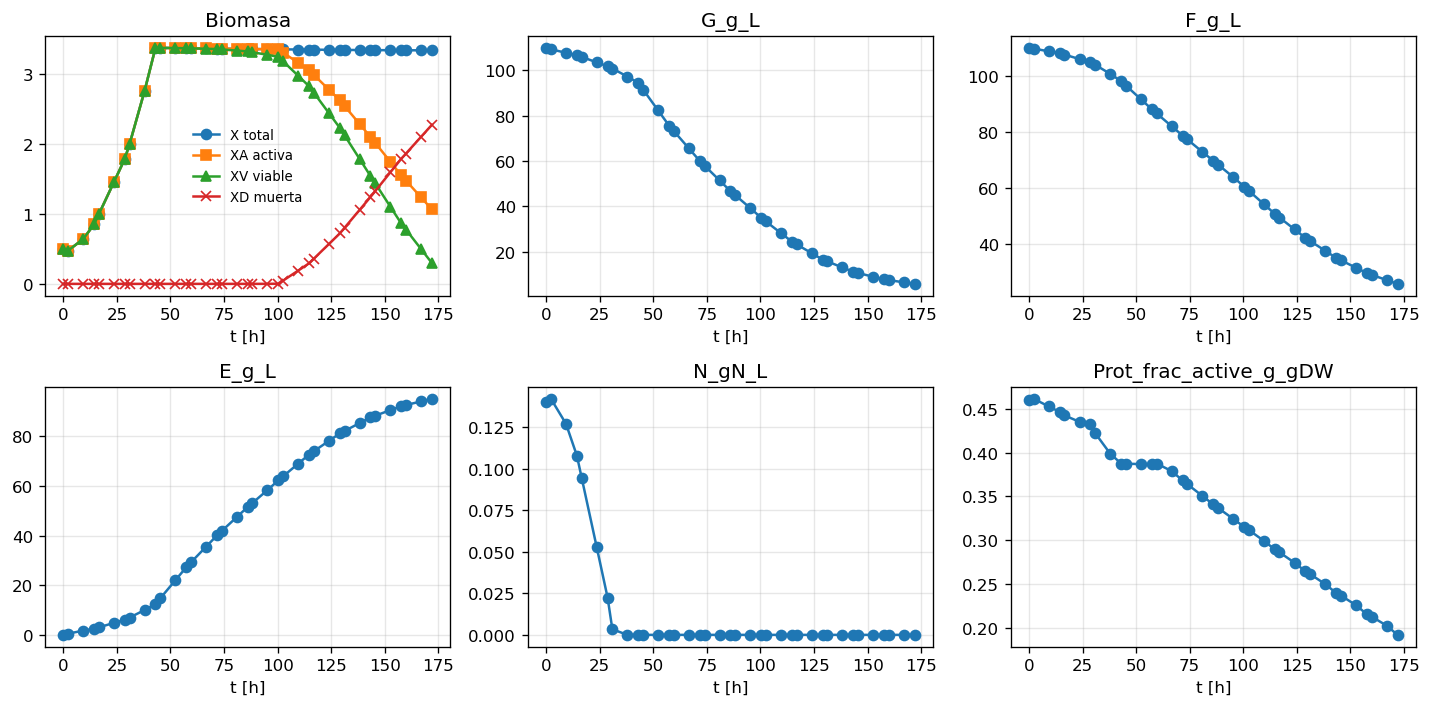

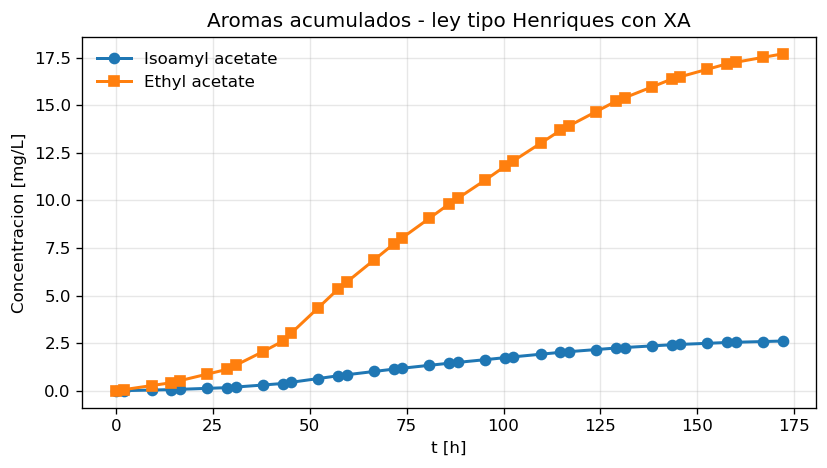

In [50]:
if RUN_SMOKE_TEST:
    res = run_dfba_collocation(
        model,
        y0=initial_state(PARAMS),
        params=PARAMS,
        t_end=SMOKE_T_END_H,
        nfe=SMOKE_NFE,
        ncp=3,
        n_iter=SMOKE_N_ITER,
        use_pfba=True,
    )
    states_df = res["states_df"]
    fluxes_df = res["fluxes_df"]
    diagnostics_df = res["diagnostics_df"]

    states_df["Prot_frac_active_g_gDW"] = states_df["Prot_g_L"] / states_df["XA_gDW_L"].clip(lower=EPS)
    states_df["Prot_frac_total_g_gDW"] = states_df["Prot_g_L"] / states_df["X_gDW_L"].clip(lower=EPS)
    states_df["Prot_frac_g_gDW"] = states_df["Prot_frac_active_g_gDW"]
    states_df["XA_frac_total"] = states_df["XA_gDW_L"] / states_df["X_gDW_L"].clip(lower=EPS)
    states_df["XV_frac_active"] = states_df["XV_gDW_L"] / states_df["XA_gDW_L"].clip(lower=EPS)
    states_df["YAN_total_gN_L"] = states_df["N_gN_L"] + states_df[AROMA_AA_STATE_NAMES].sum(axis=1)

    display(diagnostics_df[[
        "t_h", "status", "phase", "mode", "gam", "XA_gDW_L", "XV_gDW_L", "XD_gDW_L",
        "YAN_total_gN_L", "AA_leu_gN_L", "AA_val_gN_L", "AA_phe_gN_L", "AA_met_gN_L",
        "AA_leu_factor", "isoamyl_acetate_AA_factor",
        "glucose_cap", "fructose_cap", "fermentation_hexose",
        "active_decay_rate", "viability_loss_rate",
        "v_isoamyl_acetate_henriques", "v_ethyl_acetate_henriques",
    ]])
    print("LPs optimos:", int((diagnostics_df["status"] == "optimal").sum()), "/", len(diagnostics_df))
    print("Rangos de estados:")
    display(states_df[STATE_NAMES].agg(["min", "max"]).T)

    tol = 1e-6
    for col in ["G_g_L", "F_g_L", "N_gN_L", "X_gDW_L", "XA_gDW_L", "XV_gDW_L", "XD_gDW_L", *AROMA_AA_STATE_NAMES]:
        assert states_df[col].min() >= -tol, f"Estado negativo en {col}"

    fig, axes = plt.subplots(2, 3, figsize=(12, 6), dpi=120)
    axes = axes.ravel()
    axes[0].plot(states_df["t_h"], states_df["X_gDW_L"], marker="o", lw=1.5, label="X total")
    axes[0].plot(states_df["t_h"], states_df["XA_gDW_L"], marker="s", lw=1.5, label="XA activa")
    axes[0].plot(states_df["t_h"], states_df["XV_gDW_L"], marker="^", lw=1.5, label="XV viable")
    axes[0].plot(states_df["t_h"], states_df["XD_gDW_L"], marker="x", lw=1.5, label="XD muerta")
    axes[0].set_title("Biomasa")
    axes[0].set_xlabel("t [h]")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(frameon=False, fontsize=8)

    plot_cols = ["G_g_L", "F_g_L", "E_g_L", "N_gN_L", "Prot_frac_active_g_gDW"]
    for ax, col in zip(axes[1:], plot_cols):
        ax.plot(states_df["t_h"], states_df[col], marker="o", lw=1.5)
        ax.set_title(col)
        ax.set_xlabel("t [h]")
        ax.grid(True, alpha=0.3)
    fig.tight_layout()

    fig_aa, ax_aa = plt.subplots(figsize=(7, 4), dpi=120)
    for col in AROMA_AA_STATE_NAMES:
        ax_aa.plot(states_df["t_h"], states_df[col], marker="o", lw=1.5, label=col.replace("AA_", "").replace("_gN_L", ""))
    ax_aa.set_title("Aminoacidos aroma clave")
    ax_aa.set_xlabel("t [h]")
    ax_aa.set_ylabel("gN/L")
    ax_aa.grid(True, alpha=0.3)
    ax_aa.legend(frameon=False, ncols=2)
    fig_aa.tight_layout()

    fig_aroma, ax_aroma = plt.subplots(figsize=(7, 4), dpi=120)
    ax_aroma.plot(states_df["t_h"], states_df["isoamyl_acetate_mg_L"], marker="o", lw=1.8, label="Isoamyl acetate")
    ax_aroma.plot(states_df["t_h"], states_df["ethyl_acetate_mg_L"], marker="s", lw=1.8, label="Ethyl acetate")
    ax_aroma.set_title("Aromas acumulados - ley tipo Henriques con XA")
    ax_aroma.set_xlabel("t [h]")
    ax_aroma.set_ylabel("Concentracion [mg/L]")
    ax_aroma.grid(True, alpha=0.3)
    ax_aroma.legend(frameon=False)
    fig_aroma.tight_layout()
else:
    print("RUN_SMOKE_TEST=False; funciones cargadas sin ejecutar simulacion.")


## 12. Ensayo: perfil térmico aleatorio por colocación

Este ensayo construye un perfil escalonado de temperatura en cada punto de colocación, con valores aleatorios uniformes entre 15 y 25 °C. El perfil se inyecta como `params["temperature_profile_df"]`, por lo que afecta directamente las tasas Zenteno (`betaG`, `betaF`, `mu`, `mrate`) y, por extensión, los aromas con ley directa Henriques.

,t_h,T_C,T_K
0,2.222398,22.739560,295.889560
1,9.244269,19.388784,292.538784
2,14.333333,23.585979,296.735979
3,16.555731,21.973680,295.123680
4,23.577602,15.941773,289.091773
5,28.666667,24.756224,297.906224
6,30.889065,22.611397,295.761397
7,37.910935,22.860643,296.010643
8,43.000000,16.281136,289.431136
9,45.222398,19.503859,292.653859


Ensayo térmico aleatorio por colocación
T in [15.0, 25.0] °C | seed=42
t_end=172 h | nfe=12 | n_iter=1
LPs óptimos: 36 / 36


,t_h,T_C,status,phase,mode,mu_cap,XA_gDW_L,XV_gDW_L,XD_gDW_L,fermentation_hexose,active_decay_rate,viability_loss_rate,v_isoamyl_acetate_henriques,v_ethyl_acetate_henriques
0,2.222398,22.739560,optimal,lag,LAG_ATPM,0.119124,0.487847,0.487847,0.000000e+00,3.224589,1.676841e-13,1.333847e-11,0.000064,0.000645
1,9.244269,19.388784,optimal,growth,BIOMASS_PFBA,0.091707,0.586867,0.586867,0.000000e+00,2.998518,3.209172e-15,1.021698e-09,0.000060,0.000600
2,14.333333,23.585979,optimal,growth,BIOMASS_PFBA,0.127079,0.745875,0.745875,0.000000e+00,3.282362,4.545179e-13,4.040670e-09,0.000066,0.000656
3,16.555731,21.973680,optimal,growth,BIOMASS_PFBA,0.110732,0.868185,0.868185,0.000000e+00,3.045316,9.384336e-14,9.434222e-09,0.000061,0.000609
4,23.577602,15.941773,optimal,growth,BIOMASS_PFBA,0.068747,1.095317,1.095317,0.000000e+00,2.609874,7.459009e-17,3.444786e-08,0.000052,0.000522
5,28.666667,24.756224,optimal,growth,BIOMASS_PFBA,0.136555,1.299518,1.299518,0.000000e+00,3.249159,2.487518e-12,8.149975e-08,0.000065,0.000650
6,30.889065,22.611397,optimal,growth,BIOMASS_PFBA,0.108919,1.464286,1.464286,0.000000e+00,2.965026,2.740725e-13,1.450303e-07,0.000059,0.000593
7,37.910935,22.860643,optimal,growth,BIOMASS_PFBA,0.110898,2.055211,2.055211,0.000000e+00,2.984444,3.676585e-13,6.832698e-07,0.000060,0.000597
8,43.000000,16.281136,optimal,growth,BIOMASS_PFBA,0.067559,2.398699,2.398699,0.000000e+00,2.474808,1.536368e-16,1.381505e-06,0.000049,0.000495
9,45.222398,19.503859,optimal,stationary,TURNOVER_ATPM,0.000000,2.398026,2.398018,0.000000e+00,2.485510,1.179905e-14,2.412345e-06,0.000050,0.000497


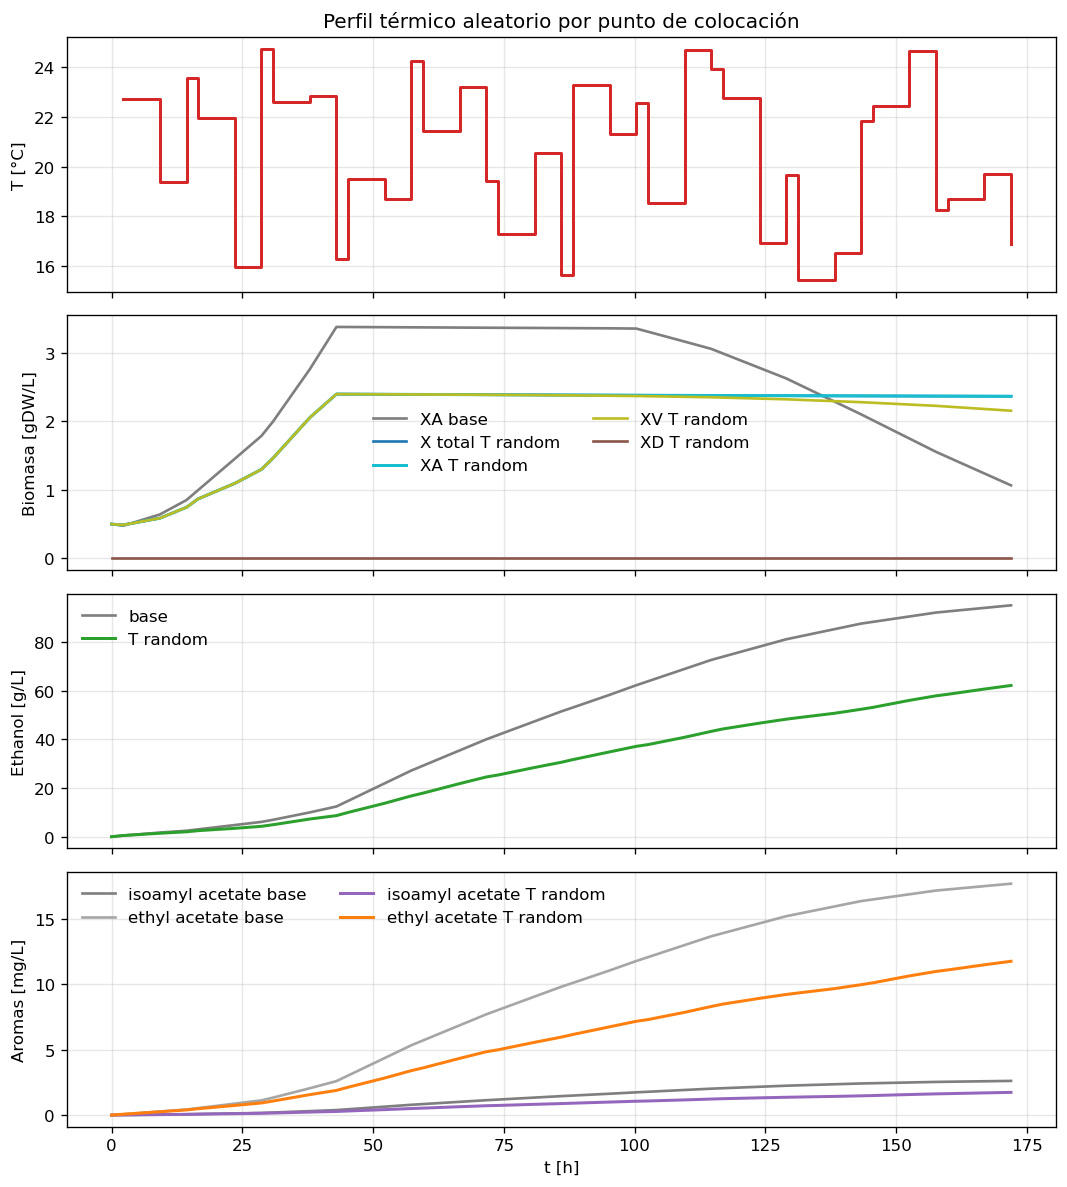

In [51]:
import copy

TEMP_RANDOM_SEED = 42
TEMP_MIN_C = 15.0
TEMP_MAX_C = 25.0
TEMP_NFE = int(globals().get("TEMP_NFE", globals().get("SMOKE_NFE", 3)))
TEMP_T_END_H = float(globals().get("TEMP_T_END_H", globals().get("SMOKE_T_END_H", 12.0)))
TEMP_N_ITER = int(globals().get("TEMP_N_ITER", globals().get("SMOKE_N_ITER", 1)))
TEMP_NCP = 3

# Misma malla Radau que el solver: un valor de temperatura por punto de colocación.
h_temp = TEMP_T_END_H / TEMP_NFE
temp_t_loc = np.array([
    i * h_temp + RADAU_ROOTS[j] * h_temp
    for i in range(TEMP_NFE)
    for j in range(TEMP_NCP)
], dtype=float)

rng = np.random.default_rng(TEMP_RANDOM_SEED)
temp_profile_df = pd.DataFrame({
    "t_h": temp_t_loc,
    "T_C": rng.uniform(TEMP_MIN_C, TEMP_MAX_C, size=len(temp_t_loc)),
})
temp_profile_df["T_K"] = temp_profile_df["T_C"] + 273.15

display(temp_profile_df)

params_temp_random = copy.deepcopy(PARAMS)
params_temp_random["temperature_profile_df"] = temp_profile_df
params_temp_random["temperature_profile_label"] = f"random_uniform_{TEMP_MIN_C:g}_{TEMP_MAX_C:g}_C_by_collocation"
params_temp_random["temperature_profile_mode"] = "step"
params_temp_random["enable_henriques_aroma_ode"] = True
params_temp_random["enable_henriques_product_caps"] = True

res_temp_random = run_dfba_collocation(
    model,
    y0=initial_state(params_temp_random),
    params=params_temp_random,
    t_end=TEMP_T_END_H,
    nfe=TEMP_NFE,
    ncp=TEMP_NCP,
    n_iter=TEMP_N_ITER,
    use_pfba=True,
)

states_temp_random = res_temp_random["states_df"].copy()
fluxes_temp_random = res_temp_random["fluxes_df"].copy()
diagnostics_temp_random = res_temp_random["diagnostics_df"].copy()
states_temp_random["Prot_frac_active_g_gDW"] = states_temp_random["Prot_g_L"] / states_temp_random["XA_gDW_L"].clip(lower=EPS)
states_temp_random["Prot_frac_total_g_gDW"] = states_temp_random["Prot_g_L"] / states_temp_random["X_gDW_L"].clip(lower=EPS)
states_temp_random["Prot_frac_g_gDW"] = states_temp_random["Prot_frac_active_g_gDW"]
states_temp_random["XA_frac_total"] = states_temp_random["XA_gDW_L"] / states_temp_random["X_gDW_L"].clip(lower=EPS)
states_temp_random["XV_frac_active"] = states_temp_random["XV_gDW_L"] / states_temp_random["XA_gDW_L"].clip(lower=EPS)
states_temp_random["YAN_total_gN_L"] = states_temp_random["N_gN_L"] + states_temp_random[AROMA_AA_STATE_NAMES].sum(axis=1)

diagnostics_temp_random["T_C"] = diagnostics_temp_random["t_h"].map(
    lambda tt: dynamic_temperature(float(tt), params_temp_random) - 273.15
)

print("Ensayo térmico aleatorio por colocación")
print(f"T in [{TEMP_MIN_C}, {TEMP_MAX_C}] °C | seed={TEMP_RANDOM_SEED}")
print(f"t_end={TEMP_T_END_H:.3g} h | nfe={TEMP_NFE} | n_iter={TEMP_N_ITER}")
print("LPs óptimos:", int((diagnostics_temp_random["status"] == "optimal").sum()), "/", len(diagnostics_temp_random))

display(diagnostics_temp_random[[
    "t_h", "T_C", "status", "phase", "mode", "mu_cap",
    "XA_gDW_L", "XV_gDW_L", "XD_gDW_L", "YAN_total_gN_L",
    "AA_leu_gN_L", "AA_leu_factor", "isoamyl_acetate_AA_factor",
    "fermentation_hexose", "active_decay_rate", "viability_loss_rate",
    "v_isoamyl_acetate_henriques", "v_ethyl_acetate_henriques",
]])

fig_temp, ax_temp = plt.subplots(4, 1, figsize=(9, 10), dpi=120, sharex=True)
ax_temp[0].step(temp_profile_df["t_h"], temp_profile_df["T_C"], where="post", color="tab:red", lw=1.8)
ax_temp[0].set_ylabel("T [°C]")
ax_temp[0].set_title("Perfil térmico aleatorio por punto de colocación")
ax_temp[0].grid(True, alpha=0.3)

if "states_df" in globals() and "XA_gDW_L" in states_df.columns:
    ax_temp[1].plot(states_df["t_h"], states_df["XA_gDW_L"], color="tab:gray", lw=1.6, label="XA base")
ax_temp[1].plot(states_temp_random["t_h"], states_temp_random["X_gDW_L"], color="tab:blue", lw=1.6, label="X total T random")
ax_temp[1].plot(states_temp_random["t_h"], states_temp_random["XA_gDW_L"], color="tab:cyan", lw=1.8, label="XA T random")
ax_temp[1].plot(states_temp_random["t_h"], states_temp_random["XV_gDW_L"], color="tab:olive", lw=1.6, label="XV T random")
ax_temp[1].plot(states_temp_random["t_h"], states_temp_random["XD_gDW_L"], color="tab:brown", lw=1.6, label="XD T random")
ax_temp[1].set_ylabel("Biomasa [gDW/L]")
ax_temp[1].grid(True, alpha=0.3)
ax_temp[1].legend(frameon=False, ncols=2)

if "states_df" in globals():
    ax_temp[2].plot(states_df["t_h"], states_df["E_g_L"], color="tab:gray", lw=1.6, label="base")
ax_temp[2].plot(states_temp_random["t_h"], states_temp_random["E_g_L"], color="tab:green", lw=1.8, label="T random")
ax_temp[2].set_ylabel("Ethanol [g/L]")
ax_temp[2].grid(True, alpha=0.3)
ax_temp[2].legend(frameon=False)

if "states_df" in globals():
    ax_temp[3].plot(states_df["t_h"], states_df["isoamyl_acetate_mg_L"], color="tab:gray", lw=1.6, label="isoamyl acetate base")
    ax_temp[3].plot(states_df["t_h"], states_df["ethyl_acetate_mg_L"], color="0.65", lw=1.6, label="ethyl acetate base")
ax_temp[3].plot(states_temp_random["t_h"], states_temp_random["isoamyl_acetate_mg_L"], color="tab:purple", lw=1.8, label="isoamyl acetate T random")
ax_temp[3].plot(states_temp_random["t_h"], states_temp_random["ethyl_acetate_mg_L"], color="tab:orange", lw=1.8, label="ethyl acetate T random")
ax_temp[3].set_ylabel("Aromas [mg/L]")
ax_temp[3].set_xlabel("t [h]")
ax_temp[3].grid(True, alpha=0.3)
ax_temp[3].legend(frameon=False, ncols=2)
fig_temp.tight_layout()


## 13. Extension prevista

- Para probar hexosas tipo Henriques: `PARAMS["kinetic_form"] = "henriques_hexose"`.
- Los aromas se integran directamente desde `vP = kP * fermentation_hexose_Zenteno(T) * f_AA`, y ademas quedan como caps suaves en exchanges.
- El siguiente paso es calibrar `product_k`, `aroma_aa_K_gN_L` y las fracciones iniciales de aminoacidos contra datos experimentales.